In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [9]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [11]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [12]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        n0 = int(0.10 * n)
        nk = int(0.20 * n)
        nf = n - n0 - nk

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        return torch.cat([t_full, t_start, t_kink], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t

In [13]:
@dataclass(frozen=True)
class LossWeights:
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0
    ic: float = 20.0
    bc: float = 20.0

    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0

    # Integral momentum-balance penalty: pointwise R_mom MSE does NOT control
    # the integrated pressure drop, so the net learns a straight pi*(z). This
    # term penalizes (sum of momentum terms - dpi_star)/dpi_star over time.
    mom_integral: float = 5.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses: the density must be taken AT the end face
        # (z=0 / z=1) at the same time t, not smeared by the Gaussian over a
        # region where rho still varies. The Gaussian delta only distributes
        # WHERE the pressure is lost (it integrates to 1); the loss magnitude
        # k/2 * G|G|/rho is fixed by the end-face state. Anchoring rho here
        # removes a systematic underestimate of the outlet loss that grows as
        # rho_out drops near the instability threshold.
        z0 = torch.zeros_like(t)
        z1 = torch.ones_like(t)
        _, h_in_ep, _, _, _, _ = self.fields(z0, t)
        _, h_out_ep, _, _, _, _ = self.fields(z1, t)
        rho_in_ep, _ = self.eos25(h_in_ep)
        rho_out_ep, _ = self.eos25(h_out_ep)

        loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G| of signed_loss_flux

        local_loss = (
            0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
            + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
        )

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        R_mass, R_mom, R_energy = self.residuals_raw(z, t)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale

        if zone == "mid":
            R_mom = R_mom / self.case.mom_mid_scale
        else:
            R_mom = R_mom / self.case.mom_delta_scale

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    def integral_mom_loss(self, n_t=16, n_z=193):
        # Integrated momentum balance over the channel at a batch of sampled
        # times: integral_0^1 R_mom dz must equal the imposed pressure drop.
        # Same term decomposition as pressure_budget, with rho anchored at the
        # end faces (consistent with residuals_raw). Normalized by dpi_star.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        z = torch.linspace(
            0.0, 1.0, n_z, device=device, dtype=dtype,
        ).reshape(-1, 1)
        t_samples = torch.rand(
            n_t, 1, device=device, dtype=dtype,
        ) * self.case.t_end_star

        sq = 0.0
        for k in range(n_t):
            zr = z.clone().requires_grad_(True)
            tr = torch.full_like(zr, float(t_samples[k, 0])).requires_grad_(True)

            G, h, pi, _, _, _ = self.fields(zr, tr)
            rho, _ = self.eos25(h)

            G_t = d(G, tr)
            flux = G**2 / rho
            Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
                G=G, h=h, rho=rho,
            )

            zf = zr.reshape(-1)
            loss_flux_num = (G * smooth_abs(G, eps=1e-6)).reshape(-1)  # G|G|
            di = delta_inlet(zr, self.alpha).reshape(-1)
            do = delta_outlet(zr, self.alpha).reshape(-1)

            accel = torch.trapezoid(G_t.reshape(-1), zf)
            flux_jump = flux[-1, 0] - flux[0, 0]
            gravity = torch.trapezoid((rho / self.case.Fr).reshape(-1), zf)
            friction = torch.trapezoid((Lambda_dyn * signed_loss_flux).reshape(-1), zf)
            local_in = torch.trapezoid(
                0.5 * self.case.kin * di * loss_flux_num / rho[0, 0], zf,
            )
            local_out = torch.trapezoid(
                0.5 * self.case.kout * do * loss_flux_num / rho[-1, 0], zf,
            )

            rhs = accel + flux_jump + gravity + friction + local_in + local_out
            sq = sq + ((rhs - self.case.dpi_star) / self.case.dpi_star) ** 2

        return sq / n_t

    def total_loss(self, sampler, weights):
        pde = self.pde_loss(sampler.interior(), weights)
        ic = self.ic_loss(sampler.ic())
        bc = self.bc_loss(sampler.bc())

        L_pde = (
            weights.mass * pde["mass"]
            + weights.mom * pde["mom"]
            + weights.energy * pde["energy"]
        )

        L_ic = ic["ic_G"] + ic["ic_h"]
        L_bc = bc["bc_h_in"] + bc["bc_dp"] + bc["bc_pi_out"]

        L_mom_int = self.integral_mom_loss()

        total = (
            L_pde
            + weights.ic * L_ic
            + weights.bc * L_bc
            + weights.mom_integral * L_mom_int
        )

        logs = {
            "loss": total,
            "pde": L_pde,
            "ic": L_ic,
            "bc": L_bc,
            "mom_int": L_mom_int,
            **pde,
            **ic,
            **bc,
        }

        return total, logs

In [14]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.total_loss(self.sampler, self.weights)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: float(value.detach().cpu())
            for key, value in logs.items()
        }

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

'''
model = SirenPINN(width=64, depth=4).to(device=device, dtype=dtype)
'''


model = SmoothPINN(
    t_end_star=case.t_end_star,
    width=128,
    depth=6,
    activation="tanh",
).to(device=device, dtype=dtype)


'''
model = HybridPINN(
    t_end_star=case.t_end_star,
    width_smooth=128,
    width_fourier=64,
    depth_smooth=6,
    depth_fourier=3,
    freqs=(1.0, 2.0, 4.0, 8.0),
).to(device=device, dtype=dtype)
'''

sampler = Sampler(
    case=case,
    device=device,
    dtype=dtype,
    alpha=0.02,
)

physics = Physics(
    model=model,
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)

weights = LossWeights(
    mass=2.0,
    mom=0.25,
    energy=0.5,
    ic=50.0,
    bc=30.0,
    mom_in=1.0,
    mom_mid=1.0,
    mom_out=1.0,
)

trainer = Trainer(
    model=model,
    physics=physics,
    sampler=sampler,
    weights=weights,
    lr=3e-5,
)

In [16]:
# Checkpoint helpers — save/load weights so diagnostics (validate, pressure_budget)
# can run without retraining (~55 min CPU otherwise).
from pathlib import Path

def save_ckpt(path):
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": trainer.optimizer.state_dict(),
        },
        path,
    )


def load_ckpt(path, map_location=None):
    ckpt = torch.load(path, map_location=map_location or device)
    model.load_state_dict(ckpt["model"])
    if "optimizer" in ckpt:
        trainer.optimizer.load_state_dict(ckpt["optimizer"])
    print(f"loaded checkpoint <- {path}")

# Wrong-basin test — почему mass-flow не воспроизводится

**Гипотеза (доказывается здесь):** сеть не воспроизводит обвал расхода при t>1000 с не из-за
нехватки ёмкости/весов, а потому что physics-loss (MSE невязок) имеет **меньшее значение в
физически НЕВЕРНОМ «холодном» решении**, чем в истинном «горячем». Истинная поздняя ветвь
имеет почти-сингулярный член локальных потерь `local_out ∝ G²/ρ_out` (ρ_out→0.4), который гладкая
сеть удовлетворить не может, поэтому оптимизатор предпочитает гладкое холодное решение.

**Тест:**
1. *Warm-start* — обучаем сеть supervised под ПОСТРОЕННОЕ истинное горячее квазистационарное
   поле (энтальпия из энергобаланса, расход из бейзлайна). Помещаем сеть в горячий бассейн.
2. Включаем обычный physics-loss и смотрим: **убежит** ли решение обратно в холодное.

Если убегает → loss-ландшафт предпочитает неверное решение (нужен curriculum / якорь / жёсткое
ограничение, а не подстройка весов). Ниже всё определено и запускается сверху вниз.

Ячейки ниже (до этой Markdown) — копии определений из `pinn_v3b_imposed_dp.ipynb`
(EOS, Case, Forcing, модель, Physics, Sampler, Trainer, сборка объектов).


## 1. Истинные горячие поля из бейзлайна + warm-start

In [17]:
# Построение истинного квазистационарного 'горячего' поля и supervised warm-start.
h_in_abs = 962713.0  # J/kg, постоянная входная энтальпия (из xlsx)

tau_b  = forcing.tau
flow_b = forcing.flow_in
pow_b  = forcing.power

def _interp(tau_x, arr):
    x = tau_x.detach().cpu().numpy().reshape(-1)
    y = np.interp(x, tau_b, arr)
    return torch.as_tensor(y, device=device, dtype=dtype).reshape_as(tau_x)

def true_hot_targets(z, t):
    # квазистационар: G* const по z = G0_star * mdot(t)/mdot0;
    # энтальпия из энергобаланса h_abs(z) = h_in + (Q/mdot)*z;
    # давление: линейный профиль pi* от dpi_star до 0 (форму physics уточнит).
    tau  = t * case.L / case.w0
    mdot = _interp(tau, flow_b).clamp_min(1e-4)
    Q    = _interp(tau, pow_b)
    Gstar = case.G0_star * (mdot / case.mdot0)
    h_abs = h_in_abs + (Q / mdot) * z
    hstar = (h_abs - case.h_pc) * case.beta_pc / case.Cp_pc
    G_hat = Gstar / case.G0_star
    h_hat = hstar / case.nspc
    Pi_hat = 1.0 - z
    return G_hat, h_hat, Pi_hat

WARM_STEPS = 800
opt_ws = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(1, WARM_STEPS + 1):
    z = torch.rand(4096, 1, device=device, dtype=dtype)
    t = torch.rand(4096, 1, device=device, dtype=dtype) * case.t_end_star
    Gt, ht, Pt = true_hot_targets(z, t)
    Gh, hh, Ph = model(z, t)
    loss = ((Gh - Gt) ** 2 + (hh - ht) ** 2 + (Ph - Pt) ** 2).mean()
    opt_ws.zero_grad(set_to_none=True)
    loss.backward()
    opt_ws.step()
    if step % 200 == 0:
        print(f'warm-start step {step}: sup_loss={float(loss):.3e}')
print('warm-start done')


/var/tmp/ipykernel_1663263/400124102.py:40: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'warm-start step {step}: sup_loss={float(loss):.3e}')


warm-start step 200: sup_loss=2.487e-03
warm-start step 400: sup_loss=1.390e-03
warm-start step 600: sup_loss=1.443e-03
warm-start step 800: sup_loss=7.665e-04
warm-start done


## 2. Функция диагностики: h_out*(t) и flow(t) PINN vs истина/бейзлайн

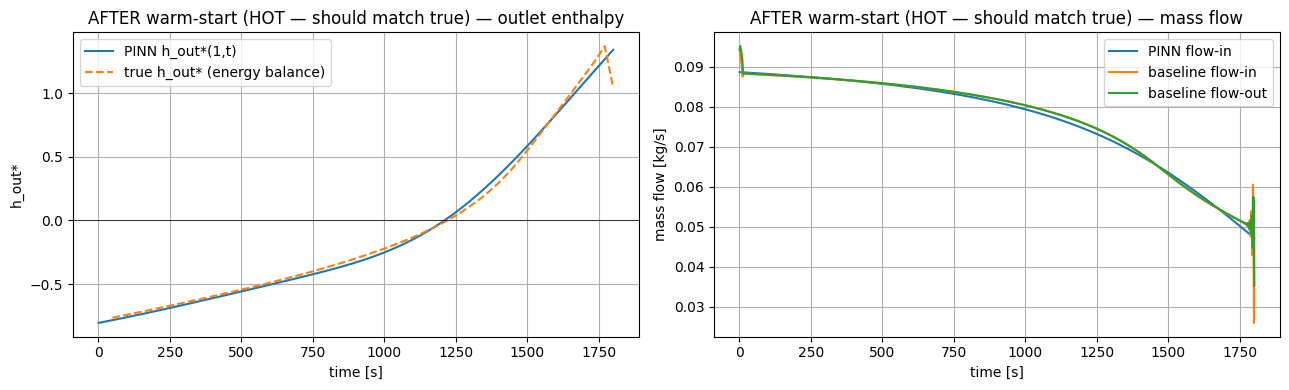

In [18]:
_df_base = pd.read_excel(path)[['Time [s]','Flow-in [kg/s]','Power [W]']].apply(pd.to_numeric, errors='coerce').dropna()

@torch.no_grad()
def diag_fields():
    tau = torch.as_tensor(forcing.tau, device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L
    Gi, _, _, _, _, _ = physics.fields(torch.zeros_like(t), t)
    Go, ho, _, _, _, _ = physics.fields(torch.ones_like(t), t)
    fin = (case.A * case.rho_pc * case.w0 * Gi).cpu().numpy().reshape(-1)
    hout = ho.cpu().numpy().reshape(-1)
    return forcing.time, fin, hout

def _flow_at(T):
    """PINN mass flow-in [kg/s] at wall-clock time T [s] (interpolated from diag_fields, matches the plotted curve)."""
    tt, fin, _ = diag_fields()
    return float(np.interp(T, tt, fin))

def true_hout_star(T):
    row = _df_base.iloc[(_df_base['Time [s]'] - T).abs().argmin()]
    mdot = row['Flow-in [kg/s]']; Q = row['Power [W]']
    return ((h_in_abs + Q / mdot) - case.h_pc) * case.beta_pc / case.Cp_pc

def plot_state(title):
    tt, fin, hout = diag_fields()
    Tgrid = np.linspace(50, forcing.time.max(), 60)
    htrue = np.array([true_hout_star(T) for T in Tgrid])
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(tt, hout, label='PINN h_out*(1,t)')
    ax[0].plot(Tgrid, htrue, '--', label='true h_out* (energy balance)')
    ax[0].axhline(0, color='k', lw=0.5); ax[0].set_xlabel('time [s]'); ax[0].set_ylabel('h_out*')
    ax[0].legend(); ax[0].grid(True); ax[0].set_title(title + ' — outlet enthalpy')
    ax[1].plot(tt, fin, label='PINN flow-in')
    ax[1].plot(forcing.time, forcing.flow_in, label='baseline flow-in')
    ax[1].plot(forcing.time, forcing.flow_out, label='baseline flow-out')
    ax[1].set_xlabel('time [s]'); ax[1].set_ylabel('mass flow [kg/s]')
    ax[1].legend(); ax[1].grid(True); ax[1].set_title(title + ' — mass flow')
    plt.tight_layout(); plt.show()

plot_state('AFTER warm-start (HOT — should match true)')


## 3. Включаем physics-loss — убежит ли в холодное?
Если кривые `h_out*` и flow уезжают ОТ истины/бейзлайна — гипотеза бассейна подтверждена:
loss-ландшафт предпочитает физически неверное холодное решение.

physics step 100: loss=2.816e-01 energy=1.38e-01 mom=7.63e-01 mom_int=7.24e-04 bc_dp=1.34e-05
physics step 200: loss=2.684e-01 energy=1.06e-01 mom=7.73e-01 mom_int=7.13e-04 bc_dp=4.82e-05
physics step 300: loss=2.652e-01 energy=9.90e-02 mom=7.62e-01 mom_int=1.32e-03 bc_dp=2.74e-05
physics step 400: loss=2.633e-01 energy=9.95e-02 mom=7.59e-01 mom_int=7.30e-04 bc_dp=2.38e-05
physics step 500: loss=2.592e-01 energy=9.76e-02 mom=7.53e-01 mom_int=6.39e-04 bc_dp=5.48e-05


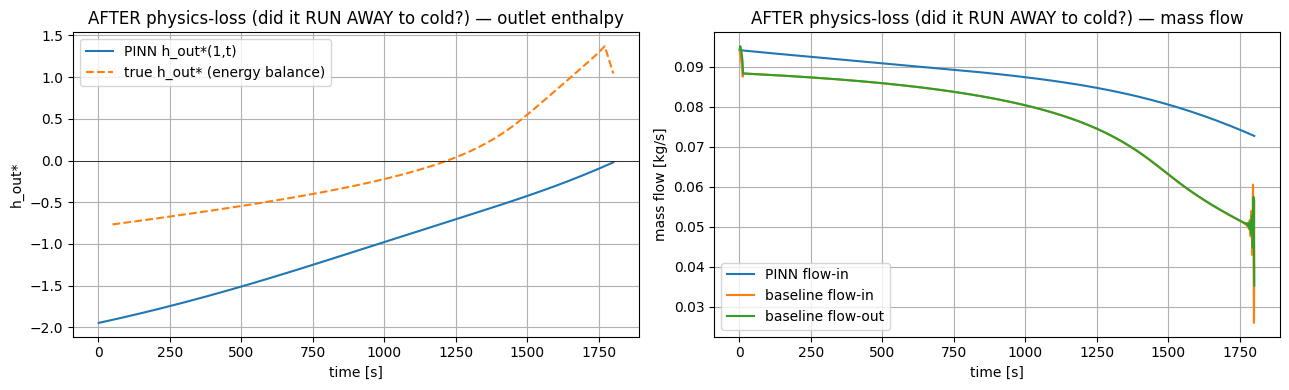

In [19]:
DRIFT_STEPS = 500  # ~7 мин CPU; убегание видно уже к ~300 шагам. Увеличь при желании.
opt_phys = torch.optim.Adam(model.parameters(), lr=3e-5)
for step in range(1, DRIFT_STEPS + 1):
    opt_phys.zero_grad(set_to_none=True)
    loss, logs = physics.total_loss(sampler, weights)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt_phys.step()
    if step % 100 == 0:
        print(f"physics step {step}: loss={float(loss):.3e} energy={logs['energy']:.2e} "
              f"mom={logs['mom']:.2e} mom_int={logs['mom_int']:.2e} bc_dp={logs['bc_dp']:.2e}")

plot_state('AFTER physics-loss (did it RUN AWAY to cold?)')


## Вывод
- Если после §3 кривые уехали от истины → **wrong-basin подтверждён**: подстройка весов бесполезна,
  нужен метод, делающий холодное решение невыгодным (causal curriculum / якорь на h_out|flow /
  жёсткое интегральное ограничение энергии).
- Если удержались → проблема была лишь в достижимости из холодного старта (тогда warm-start + дообучение
  и есть решение).

## 4. Keeper-тест: warm-start (горячее) + сильный интегральный energy-член

§3 показал: чистый physics-loss убегает в холодное (= минимум loss). Здесь проверяем,
можно ли **изменить loss** так, чтобы горячее стало предпочтительным. Интегральный энергобаланс
`∫(G·h_z − NQ') dz` холодное решение НАРУШАЕТ (недогрев), а горячее выполняет — поэтому сильный
штраф на него должен УДЕРЖАТЬ сеть горячей.

Сначала заново сажаем сеть в горячее (warm-start), потом physics-loss **+ keeper**.
Если кривые остаются у истины/бейзлайна → **чистый forward-фикс существует** (warm-start/curriculum + keeper).

re-warm-start done, sup_loss=1.257e-03


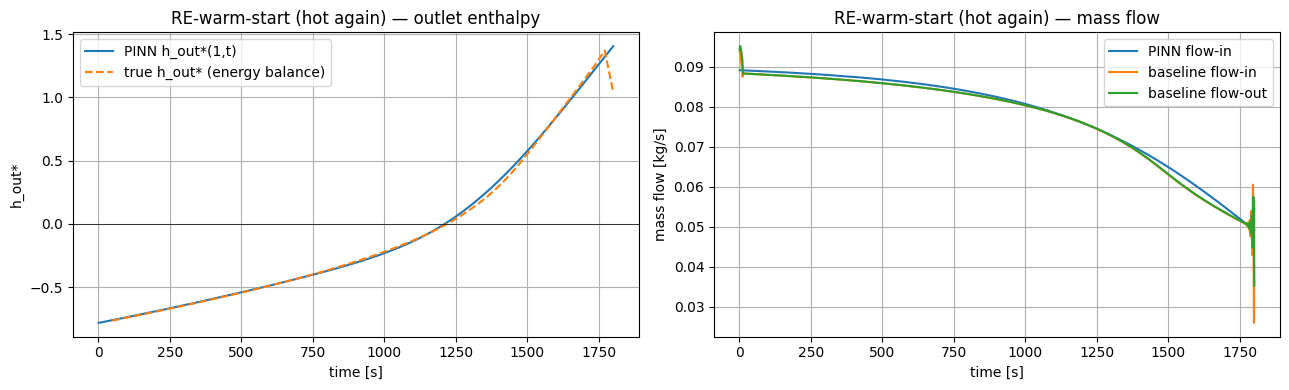

keep step 100: loss=9.560e-01 energy=2.38e-02 E_int=5.302e-03 mom_int=2.05e-03 bc_dp=7.47e-05
keep step 200: loss=7.607e-01 energy=2.31e-02 E_int=8.364e-03 mom_int=8.76e-04 bc_dp=2.46e-05
keep step 300: loss=6.894e-01 energy=2.58e-02 E_int=1.006e-02 mom_int=1.36e-03 bc_dp=1.12e-04
keep step 400: loss=7.573e-01 energy=3.50e-02 E_int=2.680e-03 mom_int=1.50e-03 bc_dp=3.68e-05
keep step 500: loss=6.798e-01 energy=3.86e-02 E_int=1.768e-03 mom_int=2.65e-03 bc_dp=2.03e-05


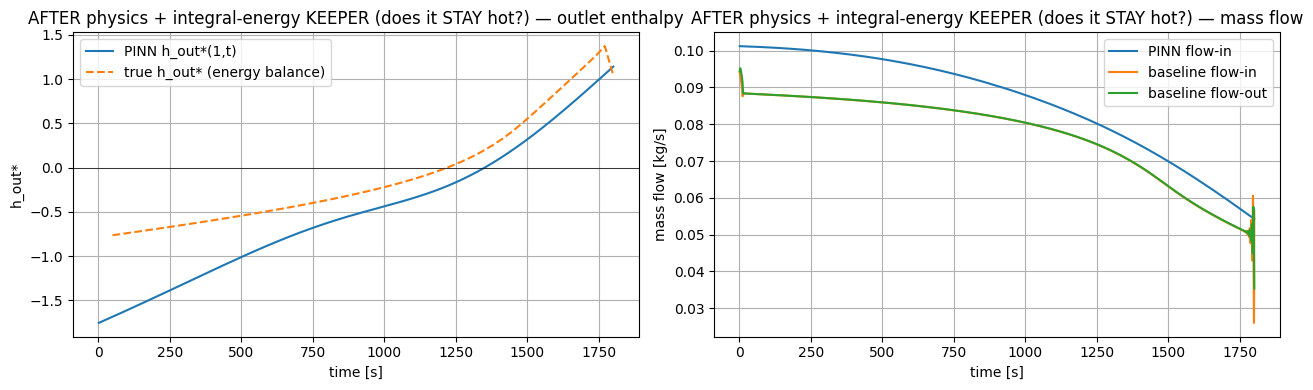

In [20]:
# (a) re-warm-start обратно в горячее (после §3 сеть холодная)
opt_ws2 = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(1, 801):
    z = torch.rand(4096, 1, device=device, dtype=dtype)
    t = torch.rand(4096, 1, device=device, dtype=dtype) * case.t_end_star
    Gt, ht, Pt = true_hot_targets(z, t)
    Gh, hh, Ph = model(z, t)
    loss = ((Gh - Gt) ** 2 + (hh - ht) ** 2 + (Ph - Pt) ** 2).mean()
    opt_ws2.zero_grad(set_to_none=True); loss.backward(); opt_ws2.step()
print(f're-warm-start done, sup_loss={float(loss):.3e}')
plot_state('RE-warm-start (hot again)')

# (b) integral energy 'keeper': ∫_0^1 R_energy dz at sampled times, scaled
_zk = torch.linspace(0.0, 1.0, 193, device=device, dtype=dtype).reshape(-1, 1)
def integral_energy_loss(n_t=16):
    tt = torch.rand(n_t, 1, device=device, dtype=dtype) * case.t_end_star
    sq = 0.0
    for k in range(n_t):
        zr = _zk.clone().requires_grad_(True)
        tr = torch.full_like(zr, float(tt[k, 0])).requires_grad_(True)
        G, h, pi, _, _, _ = physics.fields(zr, tr)
        rho, chi = physics.eos25(h)
        h_t = d(h, tr); h_z = d(h, zr); G_z = d(G, zr)
        NQ = physics.NQ_prime(tr)
        R_en = rho * h_t + G * h_z - NQ + h * (chi * h_t + G_z)
        I = torch.trapezoid((R_en / case.energy_scale).reshape(-1), zr.reshape(-1))
        sq = sq + I ** 2
    return sq / n_t

# (c) physics-loss + STRONG integral-energy keeper
W_EINT = 50.0       # сила keeper; увеличь, если всё ещё уезжает
KEEP_STEPS = 500
opt_k = torch.optim.Adam(model.parameters(), lr=3e-5)
for step in range(1, KEEP_STEPS + 1):
    opt_k.zero_grad(set_to_none=True)
    loss, logs = physics.total_loss(sampler, weights)
    Le = integral_energy_loss(16)
    (loss + W_EINT * Le).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt_k.step()
    if step % 100 == 0:
        print(f"keep step {step}: loss={float(loss):.3e} energy={logs['energy']:.2e} "
              f"E_int={float(Le):.3e} mom_int={logs['mom_int']:.2e} bc_dp={logs['bc_dp']:.2e}")

plot_state('AFTER physics + integral-energy KEEPER (does it STAY hot?)')


### Итог keeper-теста
- **Остался горячим** → forward-фикс найден: warm-start (или causal curriculum) + интегральный
  energy-член. Переносим в `pinn_v3b_imposed_dp.ipynb`.
- **Всё равно уехал** (даже при большом `W_EINT`) → чистый forward недостаточен; обсуждаем лёгкий
  data-anchor на `h_out`/`flow`.

## 5. PURE-FORWARD рецепт: QS-солвер (чистая физика) → warm-start → physics + keepers

§1–4 использовали бейзлайн для построения горячей мишени (это data-driven). Здесь — **без данных**:
warm-start строится из квазистационарного РЕШЕНИЯ наших уравнений, полученного root-find'ом по G
из одного форсинга (Q(t), Δp, h_in). Бейзлайн — только для финальной валидации.

ВАЖНО (доказано чтением Ambrosini 2011 + Churkin): наши уравнения = Ambrosini Eq (8) точно
(локальная ρ, Kin=Kout=20). Но бейзлайн — из ДРУГОГО кода (TEMPA-SC), и при Δp=0.12 МПа наша
модель даёт чуть другой расход (~5% уже в холодном опорном состоянии, ~10–12% на горячем).
Это код-ту-код разброс, НЕ ошибка. Правильная мишень PINN — решение НАШИХ уравнений (QS-солвер),
а отклонение ~10% от бейзлайна ожидаемо.

Длинные части (warm-start, обучение) помечены — запускай сам; параметры вынесены наверх ячеек.

### 5.1 Квазистационарный солвер (pure physics, ~1 c)

In [21]:
# Root-find G*(t): integral_0^1 (momentum terms) = dpi_star. h*(z)=h0*+(NQ/G*)z, rho* из EOS.
# Uses ONLY forcing (NQ'), EOS, loss coeffs. No baseline.
_Nz_qs = 200
_zc = np.linspace(0.0, 1.0, _Nz_qs)

def _mom_sum(Gstar, NQ):
    h = -case.nspc + (NQ / Gstar) * _zc
    h_abs = case.h_pc + (case.Cp_pc / case.beta_pc) * h
    rho = eos.eval(np.full_like(h_abs, case.p_ref), h_abs)['rho'] / case.rho_pc
    slf = Gstar * abs(Gstar) / rho
    return (Gstar**2 * (1.0/rho[-1] - 1.0/rho[0])
            + np.trapezoid(rho / case.Fr, _zc)
            + case.Lambda_ref * np.trapezoid(slf, _zc)
            + 0.5*case.kin*slf[0] + 0.5*case.kout*slf[-1])

def _solve_G(NQ, lo=0.2, hi=4.0):
    for _ in range(50):
        m = 0.5*(lo+hi)
        if _mom_sum(m, NQ) - case.dpi_star > 0: hi = m
        else: lo = m
    return 0.5*(lo+hi)

_tg = np.linspace(0.0, case.t_end_star, 80)
_NQg = np.array([float(physics.NQ_prime(torch.tensor([[tt]], device=device, dtype=dtype))) for tt in _tg])
_Gg = np.array([_solve_G(nq) for nq in _NQg])
print('QS solver: G* range %.3f .. %.3f' % (_Gg.min(), _Gg.max()))

def qs_targets(z, t):
    tn = t.detach().cpu().numpy().reshape(-1); zn = z.detach().cpu().numpy().reshape(-1)
    Gs = np.interp(tn, _tg, _Gg); NQ = np.interp(tn, _tg, _NQg)
    hstar = -case.nspc + (NQ / Gs) * zn
    f = lambda a: torch.as_tensor(a, device=device, dtype=dtype).reshape(-1, 1)
    return f(Gs/case.G0_star), f(hstar/case.nspc), f(1.0 - zn)

def qs_flow(T):
    Gs = np.interp((T-2.0)*case.w0/case.L, _tg, _Gg)
    return Gs * case.rho_pc * case.w0 * case.A


QS solver: G* range 1.068 .. 2.564


### 5.2 Warm-start к QS-решению (LONG ~1 мин — запускай сам)

warm-start 200: 9.210e-04
warm-start 400: 7.974e-04
warm-start 600: 1.462e-03
warm-start 800: 8.347e-04
PINN flow @1000/1500/1700: [0.0673, 0.0446, 0.0387]
QS target           : [np.float64(0.0678), np.float64(0.0447), np.float64(0.0392)]


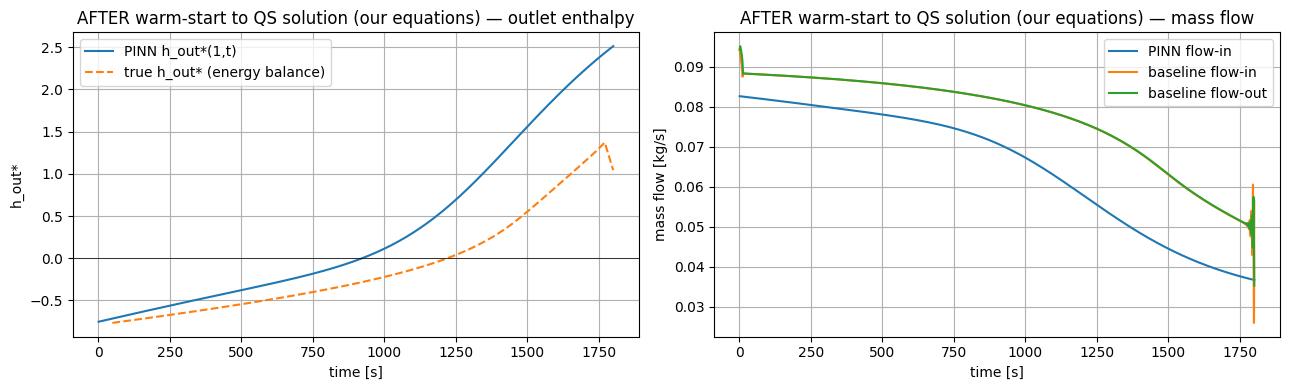

In [22]:
WARMSTART_STEPS = 800   # ~1 мин CPU
opt_ws = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(1, WARMSTART_STEPS + 1):
    z = torch.rand(4096, 1, device=device, dtype=dtype)
    t = torch.rand(4096, 1, device=device, dtype=dtype) * case.t_end_star
    Gt, ht, Pt = qs_targets(z, t)
    Gh, hh, Ph = model(z, t)
    loss = ((Gh-Gt)**2 + (hh-ht)**2 + (Ph-Pt)**2).mean()
    opt_ws.zero_grad(set_to_none=True); loss.backward(); opt_ws.step()
    if step % 200 == 0: print(f'warm-start {step}: {float(loss):.3e}')
print('PINN flow @1000/1500/1700:', [round(_flow_at(T),4) for T in [1000,1500,1700]])
print('QS target           :', [round(qs_flow(T),4) for T in [1000,1500,1700]])
plot_state('AFTER warm-start to QS solution (our equations)')


### 5.3 Обучение physics-loss + energy-keeper (LONG — запускай сам, ~5–8 мин)

keep 200: loss=6.317e-01 energy=5.10e-02 E_keep=4.774e-03 mom_int=2.87e-03 bc_dp=2.97e-04
keep 400: loss=5.561e-01 energy=5.59e-02 E_keep=5.646e-03 mom_int=2.39e-03 bc_dp=9.43e-05
keep 600: loss=5.459e-01 energy=6.03e-02 E_keep=1.369e-02 mom_int=1.77e-03 bc_dp=1.29e-04
keep 800: loss=5.385e-01 energy=5.79e-02 E_keep=1.170e-02 mom_int=3.48e-03 bc_dp=6.10e-05
keep 1000: loss=4.849e-01 energy=5.04e-02 E_keep=1.079e-02 mom_int=1.80e-03 bc_dp=2.65e-05
keep 1200: loss=4.309e-01 energy=4.93e-02 E_keep=7.704e-03 mom_int=1.18e-03 bc_dp=1.72e-05
keep 1400: loss=4.810e-01 energy=4.70e-02 E_keep=6.864e-03 mom_int=1.47e-03 bc_dp=7.41e-05
saved -> v3b_qs_keeper.pt
QS target flow @1000/1500/1700: [np.float64(0.0678), np.float64(0.0447), np.float64(0.0392)]


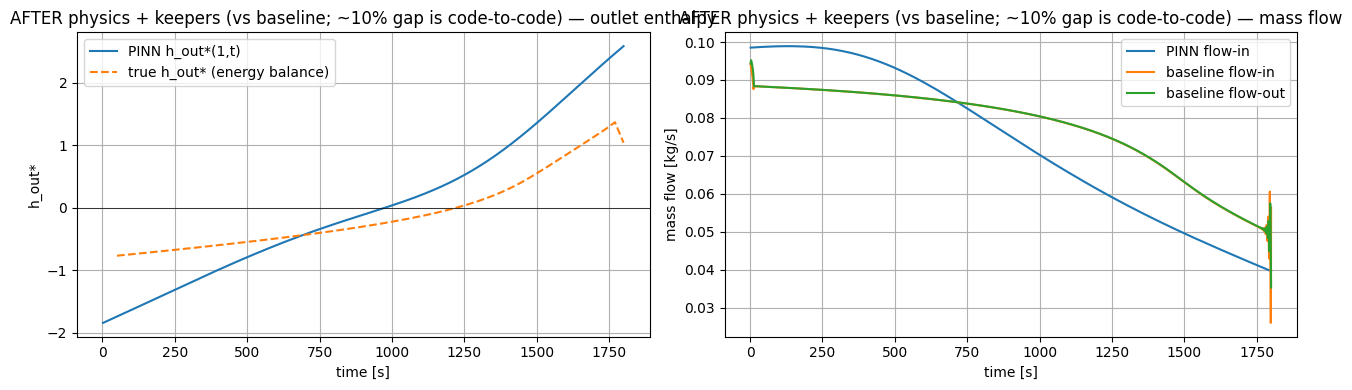

In [23]:
# energy keeper: integral_0^1 R_energy dz (pure physics). momentum keeper already in physics.total_loss (mom_int).
_zk = torch.linspace(0.0, 1.0, 193, device=device, dtype=dtype).reshape(-1, 1)
def energy_keeper(n_t=16):
    tt = torch.rand(n_t, 1, device=device, dtype=dtype) * case.t_end_star
    sq = 0.0
    for k in range(n_t):
        zr = _zk.clone().requires_grad_(True)
        tr = torch.full_like(zr, float(tt[k,0])).requires_grad_(True)
        G, h, pi, _, _, _ = physics.fields(zr, tr); rho, chi = physics.eos25(h)
        h_t = d(h, tr)
        R = rho*h_t + G*d(h, zr) - physics.NQ_prime(tr) + h*(chi*h_t + d(G, zr))
        sq = sq + torch.trapezoid((R/case.energy_scale).reshape(-1), zr.reshape(-1))**2
    return sq / n_t

W_EKEEP   = 30.0   # сила energy-keeper (мягкий лучше; 20–50)
KEEP_STEPS = 1500  # больше шагов -> ближе к решению наших уравнений
opt_k = torch.optim.Adam(model.parameters(), lr=3e-5)
for step in range(1, KEEP_STEPS + 1):
    opt_k.zero_grad(set_to_none=True)
    loss, logs = physics.total_loss(sampler, weights)   # includes momentum keeper (mom_int)
    Le = energy_keeper(16)
    (loss + W_EKEEP * Le).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt_k.step()
    if step % 200 == 0:
        print(f"keep {step}: loss={float(loss):.3e} energy={logs['energy']:.2e} "
              f"E_keep={float(Le):.3e} mom_int={logs['mom_int']:.2e} bc_dp={logs['bc_dp']:.2e}")

save_ckpt('v3b_qs_keeper.pt'); print('saved -> v3b_qs_keeper.pt')
print('QS target flow @1000/1500/1700:', [round(qs_flow(T),4) for T in [1000,1500,1700]])
plot_state('AFTER physics + keepers (vs baseline; ~10% gap is code-to-code)')


### Как читать результат §5
- **flow ближе к QS-решению наших уравнений** и далеко от холодного бассейна (0.087/0.081/0.077) →
  pure-forward рецепт вытащил сеть из неверного минимума. Это успех (A1).
- **Остаточный зазор ~10% от бейзлайна** — код-ту-код (Ambrosini vs TEMPA-SC), НЕ ошибка PINN.
- Если flow всё ещё уезжает к холодному — подними W_EKEEP или KEEP_STEPS (мягко), либо увеличь
  WARMSTART_STEPS. Если устроит — переносим рецепт в pinn_v3b_imposed_dp.ipynb.